In [12]:
using Plots
using Serialization
using LaTeXStrings
global const ind_S0 = 5;
global const ind_S1 = 6;

In [9]:
outfile_125, monitorfile_125 = open("Data files/t50_phiM_060_GBd_0125.dat","r") do io
    deserialize(io);
end;

outfile_250, monitorfile_250 = open("Data files/t50_phiM_060_GBd_0250.dat","r") do io
    deserialize(io);
end;

outfile_500, monitorfile_500 = open("Data files/t50_phiM_060_GBd_0500.dat","r") do io
    deserialize(io);
end;

In [11]:
time_arr_500 = [x[1] for x in monitorfile_500];
param_arr_500 = [x[2] for x in monitorfile_500];
p_arr_500 = [x[4] for x in monitorfile_500];
e_arr_500 = [x[3] for x in monitorfile_500];
hubble_arr_500 = [x[ind_S1]/x[ind_S0] for x in param_arr_500];

time_arr_250 = [x[1] for x in monitorfile_250];
param_arr_250 = [x[2] for x in monitorfile_250];
p_arr_250 = [x[4] for x in monitorfile_250];
e_arr_250 = [x[3] for x in monitorfile_250];
hubble_arr_250 = [x[ind_S1]/x[ind_S0] for x in param_arr_250];

time_arr_125 = [x[1] for x in monitorfile_125];
param_arr_125 = [x[2] for x in monitorfile_125];
p_arr_125 = [x[4] for x in monitorfile_125];
e_arr_125 = [x[3] for x in monitorfile_125];
hubble_arr_125 = [x[ind_S1]/x[ind_S0] for x in param_arr_125];


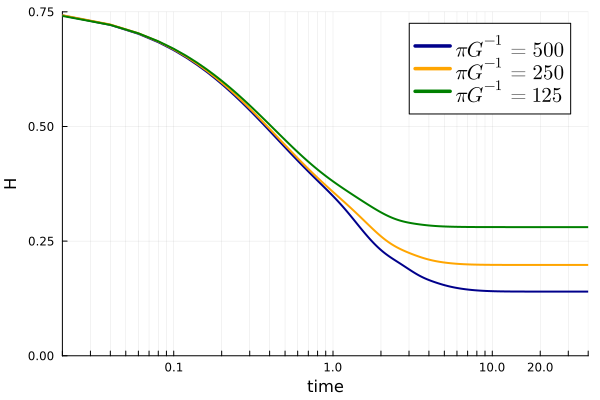

In [56]:
fig = plot(time_arr_500[2:end],hubble_arr_500[2:end],xscale=:log10,label=L"\pi G^{-1} = 500", lc=:darkblue, lw=2)
plot!(fig, time_arr_250[2:end],hubble_arr_250[2:end],xscale=:log10,label=L"\pi G^{-1} = 250", lc=:orange, lw=2)
plot!(fig, time_arr_125[2:end],hubble_arr_125[2:end],xscale=:log10,label=L"\pi G^{-1} = 125", lc=:green, lw=2)

ylabel!("H")
xlabel!("time")
xlims!(time_arr_125[2],40)
ylims!(0.,.75)
xtick_vals = vcat(0.02:0.01:0.1,0.2:0.1:1,2:1:10,20,30,40);
xlab(val) = (val in (0.1,1,10,20) ? string(val) : "");
xtick_labels = [xlab(val) for val in xtick_vals];
xticks!((xtick_vals, xtick_labels))

plot!(legendfontsize=14)

# savefig("Figs/compareDS/hubble.pdf")



In [17]:
using DelimitedFiles

data = readdlm("Data files/from_jorge/EHplot_phiM06.dat")

# Extract the two columns into separate vectors
column1 = data[:, 1];
column2 = data[:, 2];

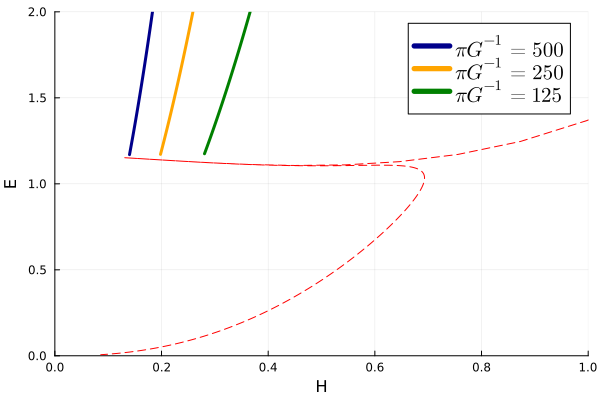

In [66]:
fig = plot(hubble_arr_500[1:1:end],e_arr_500[1:1:end],label =L"\pi G^{-1} = 500" , lc=:darkblue, lw=3)
plot!(hubble_arr_250[1:1:end],e_arr_250[1:1:end],label =L"\pi G^{-1} = 250", lc=:orange, lw=3)
plot!(hubble_arr_125[1:1:end],e_arr_125[1:1:end],label =L"\pi G^{-1} = 125",  lc=:green, lw=3)
plot!(fig, column1,column2, label = false, lc=:red, ls=:dash)

ylims!(0,2)
xlims!(0,1.)
xlabel!("H")
ylabel!("Ε")

plot!(legendfontsize=14)

# savefig("Figs/compareDS/E_vs_H.pdf")

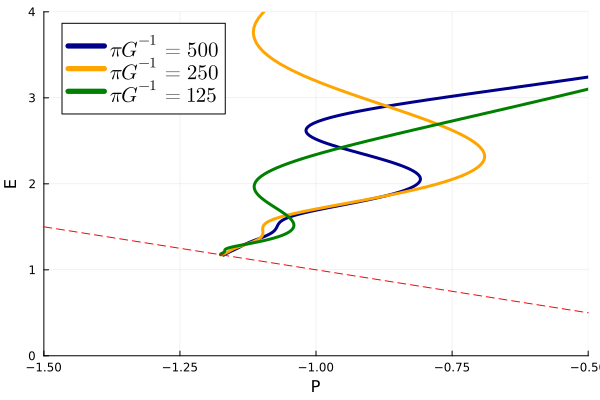

In [71]:
fig = plot(p_arr_500,e_arr_500,label =L"\pi G^{-1} = 500" , lc=:darkblue, lw=3)
plot!(fig, p_arr_250,e_arr_250,label =L"\pi G^{-1} = 250" , lc=:orange, lw=3)
plot!(fig, p_arr_125,e_arr_125,label =L"\pi G^{-1} = 125" , lc=:green, lw=3)
xlims!(-1.5,-.5)
ylims!(0,4.)
# plot!(column1, column2, label = "Equilibrium", ls=:dash)
plot!(fig, x->-x,label=false, ls=:dash, lc=:red)
ylabel!("E")
xlabel!("P")

plot!(legendfontsize=14)

# savefig("Figs/compareDS/E_vs_P.pdf")